# Study Stripping from First Principles

This follows the implementation of ``test_evolve.py`` in the SatGen repository. The code does 3 things:
1. Initialize a host halo of mass $M_{\rm UFD}$ and a single subhalo with mass $m$
2. Evolve the orbit of the subhalo in the host halo (including dynamical friction)
3. Track the mass loss of the subhalo
We initialize an NFW host halo with a virial mass of $10^9 M_\odot$ and a concentration of $11.68$. This roughly corresponds to the parameters of Segue I, which is one of the most sensitive UFD candidates. For the subhalo we take $m= 10^6 M_\odot$ as an exemplary value.

For all of this we use the SatGen routines since we eventually might also want to use it to generate the initial conditions for the system. It also has an implementation of subhalo stripping. Even though we think this description is not completely realistic and/or applicable to our scenario, it gives us a starting point to compare to.

**To Dos:**
- Run code with SatGen mass stripping and visually reproduce Tidal Tracks from Errani et al '21 https://academic.oup.com/mnras/article/505/1/18/6271332  (this is trivial since the tidal tracks are implemented in SatGen. But it might still be useful to see that it actually matches the $v_{\rm max} - r_{\rm max}$ curve in the paper)
- Implement first order method from https://iopscience.iop.org/article/10.1088/0004-637X/792/1/24 (see also https://academic.oup.com/mnras/article/517/1/1398/6726643) numerically. See that it slightly deviates from the tidal tracks. But we should try to get it close to what it looks like in Figure 1 of https://academic.oup.com/mnras/article/517/1/1398/6726643
- Implement second order method from https://academic.oup.com/mnras/article/517/1/1398/6726643, including the improved mass shell expansion formalism from http://arxiv.org/abs/2403.09597, which avoids shell crossings

**Already Done:**
- Implementation of a numeric profile class in ``subhalo_functions.py``
- A ``heat_profile`` function in ``subhalo_functions.py`` which should perform the shell expansion formalism from http://arxiv.org/abs/2403.09597 (I took it from the Fortran implementation of Galacticus https://github.com/galacticusorg/galacticus)
- An implementation of the tidal tensor computation
- A first try to perform the stripping within this file (don't trust anything... I don't think it's really working yet)

In [1]:
import config as cfg
import cosmo as co
from profiles import NFW,Dekel,Einasto,MN, Vcirc,ftot,fDF,tdyn
from orbit import orbit
import evolve as ev
import galhalo as gh

#---custom functions
import aux
from subhalo_functions import heat_profile, NumericProfile, tidalTensor

#---python modules
import numpy as np
import time 
import sys

#---for plot
import matplotlib as mpl # must import before pyplot
mpl.use('Qt5Agg')
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 15
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...
    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


## Initialize Subhalo and Host Profile

We initialize the mass resolution, the host profile and the subhalo (including its initial phase space). The subhalo has a Dekel profile (which is the standard in SatGen)

In [2]:
cfg.Mres = 1e3

#---host properties <<< use the same as used in test_profiles.py
Mv = 10.**9. # halo virial mass [Msun]
cNFW = 11.68 # NFW concentration
#
hNFW = NFW(Mv,cNFW)
potential = hNFW

#---satellite properties <<< play with
mv0 = 10.**6.#0.1 * Mv # satellite virial mass at infall [Msun]
cDekel0 = 100. # initial concentration of satellite
aDekel0 = 1.0 + cfg.eps
#
s = Dekel(mv0,cDekel0,aDekel0)

#---numeric profile of satellite
rval = np.logspace(-3,np.log10(s.rh),100)
Mval = s.M(rval)
numProfile = NumericProfile(rval, Mval)

#---initial orbit
R0 = 1
#R0 = 0.8*hNFW.rh
phi0 = 0.
#z0 = 0.6*hNFW.rh
z0 =1
VR0 = 0.
Vphi0 = Vcirc(potential,np.sqrt(R0**2+z0**2),0.)
Vz0 = 0.
#
xv0 = np.array([R0,phi0,z0,VR0,Vphi0,Vz0])
print(f"Initial phase space vector xv0 = {xv0}")

#---stripping parameterization
epsh = 3
gamma = 2.5

Initial phase space vector xv0 = [ 1.          0.          1.          0.         16.79291169  0.        ]


In [3]:
#---for evolution and bookkeeping
Nstep = 200 # number of timesteps
tmax = 10. # [Gyr] 
timesteps = np.linspace(0.,tmax,Nstep+1)[1::] #[Gyr]
print('>>> initializing ... ')
o = orbit(xv0)
r = np.sqrt(R0**2+z0**2)
m = mv0

rmax0 = s.rmax
vmax0 = s.Vmax

radius = np.zeros(Nstep)
velocity = np.zeros(Nstep)
xpos = np.zeros(Nstep)
ypos = np.zeros(Nstep)
zpos = np.zeros(Nstep)
mass = np.zeros(Nstep)
vmax = np.zeros(Nstep)
rmax = np.zeros(Nstep)
xvList = np.zeros((Nstep,6))
TidalRadius = np.zeros(Nstep)
RamPressureRadius = np.zeros(Nstep)
MassLossRate = np.zeros(Nstep)
concentration = np.zeros(Nstep)
slope = np.zeros(Nstep)
tidalHeatingRate =np.zeros(Nstep)
r_grid = np.logspace(-3,np.log10(s.rh),100)
rho_track = np.zeros((10,len(r_grid)))
M_track = np.zeros((10,len(r_grid)))

print('>>> evolving ... ')
tprevious = 0.
t1 = time.time()
tt_int = np.zeros((3,3))
tt = np.zeros((3,3))
for i,t in enumerate(timesteps):
    
    dt = t -  tprevious
    
    #---evolve orbit
    if r>cfg.Rres:
        o.integrate(t,potential,m)
        xv = o.xv
        # note that the coordinates are updated internally in the orbit 
        # instance "o", here we assign them to xv only for bookkeeping
    else: 
        continue
    r = np.sqrt(xv[0]**2+xv[2]**2)
    V = np.sqrt(xv[3]**2+xv[4]**2+xv[5]**2)
    x = xv[0]*np.cos(xv[1])
    y = xv[0]*np.sin(xv[1])
    z = xv[2]

    # compute the tidal heating rate (even though we don't use it here)
    t_orbit = tdyn(potential,r)
    tt = tidalTensor(potential, [x,y,z])
    tt_int += (tt -tt_int/t_orbit)*dt
    tidalHR = epsh/3*(1+(2*np.pi*r/V/t_orbit)**2)**(-gamma)*np.sum(tt * tt_int)
    
    #---evolve subhalo mass and profile
    if m>cfg.Mres:
        m,lt = ev.msub(s,potential,xv,dt,choice='King62',alpha=1.)
        a = s.alphah # assume: innermost slope not affected by tides 
        c,Delta = ev.Dekel(m,mv0,rmax0,vmax0,aDekel0,z=0.)
    else:
        m = cfg.Mres
        lt = cfg.Rres
        c = s.ch
        a = s.alphah
    dmdt = (s.Mh - m) / dt 
    s = Dekel(m,c,a,Delta=Delta,z=0.)
    
    #---record
    radius[i] = r
    velocity[i] = V
    mass[i] = m
    xpos[i] = x
    ypos[i] = y
    zpos[i] = z
    xvList[i,:] = xv
    TidalRadius[i] = lt
    MassLossRate[i] = dmdt
    concentration[i] = s.rh / s.rmax
    slope[i] = s.sh
    tidalHeatingRate[i] = tidalHR
    rmax[i] = s.rmax
    vmax[i] = s.Vmax

    # record the density and mass profiles for the first 10 steps
    if i<10:
        rho_track[i,:] = s.rho(r_grid)
        M_track[i,:] = s.M(r_grid)
    
    #---update tprevious
    tprevious = t

t2 = time.time()
print('    time = %.4f'%(t2-t1))

>>> initializing ... 
>>> evolving ... 
    time = 0.0827


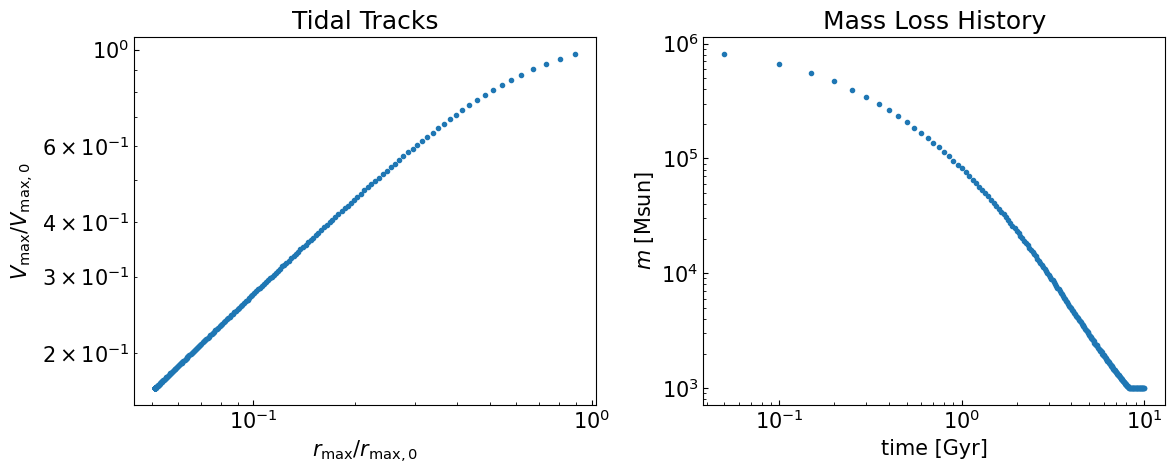

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(rmax/rmax0, vmax/vmax0,'.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$r_{\rm max}/r_{\rm max,0}$')
plt.ylabel(r'$V_{\rm max}/V_{\rm max,0}$')
plt.title("Tidal Tracks")
plt.subplot(1,2,2)
plt.plot(timesteps, mass,'.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('time [Gyr]')
plt.ylabel(r'$m$ [Msun]')
plt.title("Mass Loss History")

plt.tight_layout()
plt.show()

Now let us see how well the custom stripping procedure works

I check the first heating step by hand and compare it to the recorded profile

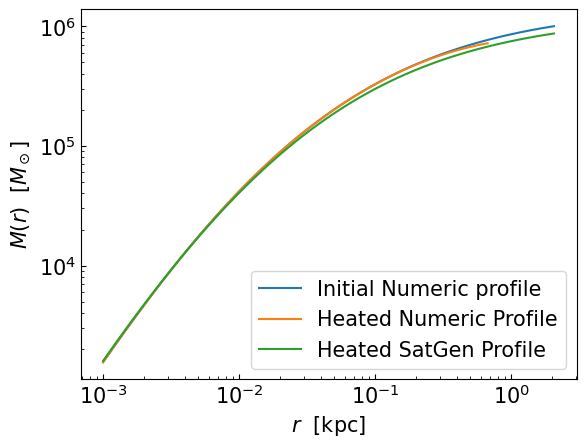

In [7]:
from scipy.optimize import brentq

# define first order heating function using the tidal heating rate computed during the evolution
def eps(r):
    return tidalHeatingRate[0]*r**2

# evolve the initial numeric profile using the first order heating function defined above, and compute the new tidal radius after heating
heatedProfile = heat_profile(numProfile, eps)
lt = ev.ltidal(heatedProfile,potential,xvList[0],'King62')

# compute the mass loss due to tidal stripping of the heated profile
dm = 1. * (heatedProfile.Mh-heatedProfile.M(lt)) * dt/tdyn(potential,xvList[0,0],xvList[0,2])
dm = max(dm,0.) # avoid negative dm
m = heatedProfile.Mh-dm

# compute the new virial radius by cutting the profile where it reaches the new mass after stripping
rmaxNew = brentq(lambda x: heatedProfile.M(x)-m, lt, heatedProfile.rh)

# plot the results and compare to SatGen results
rvals = np.logspace(-3,np.log10(rmaxNew),100)
Mvals = heatedProfile.M(rvals)
plt.plot(numProfile.ri, numProfile.Mr, '-', label='Initial Numeric profile')
plt.plot(rvals, Mvals, '-', label="Heated Numeric Profile")
plt.plot(r_grid, M_track[0], '-', label="Heated SatGen Profile")
plt.xlabel(r'$r$  [kpc]')
plt.ylabel(r'$M(r)$  [$M_\odot$]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

Now let us try to do the whole calculation with the custom heating procedure

In [66]:
#---for evolution and bookkeeping
Nstep = 200 # number of timesteps
tmax = 10. # [Gyr] 
timesteps = np.linspace(0.,tmax,Nstep+1)[1::] #[Gyr]
print('>>> initializing ... ')
o = orbit(xv0)
r = np.sqrt(R0**2+z0**2)
m = mv0

rmax0N = numProfile.rmax
vmax0N = numProfile.Vmax

radiusN = np.zeros(Nstep)
velocityN = np.zeros(Nstep)
xposN = np.zeros(Nstep)
yposN = np.zeros(Nstep)
zposN = np.zeros(Nstep)
massN = np.zeros(Nstep)
vmaxN = np.zeros(Nstep)
rmaxN = np.zeros(Nstep)
xvListN = np.zeros((Nstep,6))
TidalRadiusN = np.zeros(Nstep)
MassLossRateN = np.zeros(Nstep)
tidalHeatingRateN =np.zeros(Nstep)
r_grid = np.logspace(-3,np.log10(numProfile.rh),100)
rho_trackN = np.zeros((10,len(r_grid)))
M_trackN = np.zeros((10,len(r_grid)))

print('>>> evolving ... ')
tprevious = 0.
t1 = time.time()
tt_intN = np.zeros((3,3))
ttN = np.zeros((3,3))

for i,t in enumerate(timesteps):
    
    dt = t -  tprevious
    
    #---evolve orbit
    if r>cfg.Rres:
        o.integrate(t,potential,m)
        xv = o.xv
        # note that the coordinates are updated internally in the orbit 
        # instance "o", here we assign them to xv only for bookkeeping
    else: 
        continue
    r = np.sqrt(xv[0]**2+xv[2]**2)
    V = np.sqrt(xv[3]**2+xv[4]**2+xv[5]**2)
    x = xv[0]*np.cos(xv[1])
    y = xv[0]*np.sin(xv[1])
    z = xv[2]
    t_orbit = tdyn(potential,r)
    ttN = tidalTensor(potential, [x,y,z])
    tt_intN += (ttN-tt_intN/t_orbit)*dt
    tidalHRN = epsh/3*(1+(2*np.pi*r/V/t_orbit)**2)**(-gamma)*np.sum(ttN * tt_intN)
    Mh_old = numProfile.Mh
    print(tidalHRN)

    def eps(r):
        return dt*tidalHRN*r**2
    
    #---evolve subhalo mass and profile
    if m>cfg.Mres:
        #print(f"Mass old {m}")
        newProfile = heat_profile(numProfile, eps)
        print("here")
        lt = ev.ltidal(newProfile,potential,xv,'King62')
        if lt< newProfile.rh: 
            dm = 1. * (newProfile.Mh-newProfile.M(lt)) * dt/tdyn(potential,xv[0],xv[2])
            dm = max(dm,0.) # avoid negative dm
            if cfg.Mres is not None:
                # Fixed Mres case
                m = max(newProfile.Mh-dm, cfg.Mres)
            rmaxNew = brentq(lambda x: newProfile.M(x)-m, lt, newProfile.rh)
            rvals = np.logspace(-3,rmaxNew,100)
            Mvals = newProfile.M(rvals)
            numProfile = NumericProfile(rvals, Mvals)
        else:
            numProfile = newProfile
            m = numProfile.Mh
        #m,lt = ev.msub(s,potential,xv,dt,choice='King62',alpha=1.)
        #print(f"Mass new {m}")
        # a = s.alphah # assume: innermost slope not affected by tides 
        # c,Delta = ev.Dekel(m,mv0,lmax0,vmax0,aDekel0,z=0.)
    else:
        m = cfg.Mres
        lt = cfg.Rres
        #c = s.ch
        #a = s.alphah
    dmdt = (Mh_old - m) / dt 
    #s = Dekel(m,c,a,Delta=Delta,z=0.)
    
    #---record
    radiusN[i] = r
    velocityN[i] = V
    massN[i] = m
    xposN[i] = x
    yposN[i] = y
    zposN[i] = z
    TidalRadiusN[i] = lt
    MassLossRateN[i] = dmdt
    tidalHeatingRateN[i] = tidalHRN
    
    #---record profile at sampling times
    if i<10:
        rho_trackN[i,:] = numProfile.rho(r_grid)
        M_trackN[i,:] = numProfile.M(r_grid)
    
    #---update tprevious
    tprevious = t

t2 = time.time()
print('    time = %.4f'%(t2-t1))

>>> initializing ... 
>>> evolving ... 
1.852427587855459
here
2.6872725858287874
here
3.0908657693470922
here
3.564846086115234
here
4.053926842185173
here
4.144270835952639
here


/opt/homebrew/anaconda3/lib/python3.13/site-packages/numpy/_core/function_base.py:314: RuntimeWarning: overflow encountered in power
  return _nx.power(base, y)
/Users/mruhdorf/Documents/GitHub/SatGen/subhalo_functions.py:41: RuntimeWarning: overflow encountered in square
  r = np.sqrt(R**2 + z**2)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1515: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


ValueError: x must be increasing if s > 0